In [6]:
import os
import numpy as np
import librosa
from glob import glob
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
DATA_DIR = "global-model-processed-data"
SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
TIME_FRAMES = 256
BATCH_SIZE = 16
EPOCHS = 30

In [8]:
def extract_log_mel(path):
    y, sr = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    log_mel = librosa.power_to_db(mel)
    return log_mel


def pad_or_crop(mel):
    if mel.shape[1] < TIME_FRAMES:
        pad_width = TIME_FRAMES - mel.shape[1]
        mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel = mel[:, :TIME_FRAMES]
    return mel

In [9]:
def load_dataset(split, label):
    path = os.path.join(DATA_DIR, split, label, "*.wav")
    files = glob(path)
    features = []

    for f in files:
        mel = extract_log_mel(f)
        mel = pad_or_crop(mel)
        features.append(mel)

    X = np.array(features)[..., np.newaxis]
    return X

In [10]:
print("Loading training data...")
X_train = load_dataset("train", "normal")

print("Loading test data...")
X_test_normal = load_dataset("test", "normal")
X_test_abnormal = load_dataset("test", "abnormal")

X_test = np.concatenate([X_test_normal, X_test_abnormal], axis=0)
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_test_abnormal))
])

Loading training data...
Loading test data...


In [11]:
def build_autoencoder():
    model = models.Sequential([
        layers.Input(shape=(N_MELS, TIME_FRAMES, 1)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), activation="relu", padding="same"),

        layers.UpSampling2D((2, 2)),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),

        layers.UpSampling2D((2, 2)),
        layers.Conv2D(1, (3, 3), activation="linear", padding="same")
    ])

    model.compile(optimizer="adam", loss="mse")
    return model

In [12]:
model = build_autoencoder()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 128, 16)    │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 64, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 128, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 128, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 256, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,417 (28.97 KB)

 Trainable params: 7,417 (28.97 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("Training model...")
model.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Training model...
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 67.1703
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - loss: 11.2758
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 9.7491
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 9.1649
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 8.8708
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 8.6313
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 8.4509
Epoch 8/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 8.3096
Epoch 9/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 8.2040
Epoch 10/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 8.1233
Epoch 11/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 8.0498
Epoch 12/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 8.0175
Epoch 13/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 7.9341
Epoch 14/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 7.9079
Epoch 15/

In [14]:
print("Evaluating...")

X_recon = model.predict(X_test)
anomaly_scores = np.mean(
    np.square(X_test - X_recon),
    axis=(1, 2, 3)
)

auc = roc_auc_score(y_test, anomaly_scores)
print(f"\nROC-AUC Score: {auc:.4f}")

Evaluating...
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step

ROC-AUC Score: 0.5906


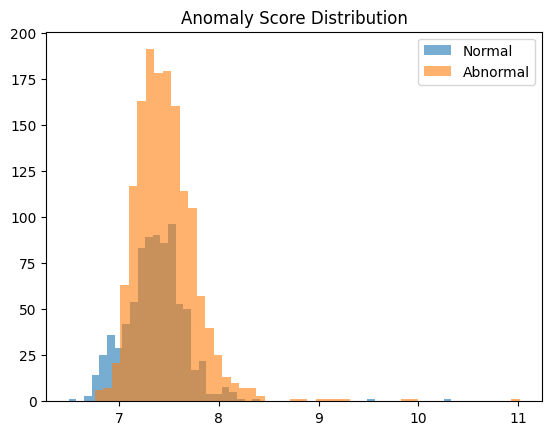

In [15]:
import matplotlib.pyplot as plt

plt.hist(anomaly_scores[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_scores[y_test == 1], bins=50, alpha=0.6, label="Abnormal")
plt.legend()
plt.title("Anomaly Score Distribution")
plt.show()
